# B3 · Transformer Attention Mechanism

Scaled dot-product attention from scratch (topic **B3** of the project catalog):
profile a CPU transformer block, find the bottleneck, and replace it — only it —
with progressively better CUDA kernels.

| Version | Attention implementation | Key idea |
|---|---|---|
| `CpuPipeline` | bare Python triple loops | sequential baseline; its O(N²) cost caps the sweep at N = 2048 |
| `GpuV1` | three naive numba kernels | one thread per output element, everything through global memory |
| `GpuV2` | tiled QK$^T$ + online softmax | shared-memory tiles + one-pass softmax: reuse over redundancy |

Everything except attention — embedding, projections, norms, FFN — stays in
PyTorch on the CPU (*partial GPU principle*): only the profiled bottleneck moves.

In [21]:
# On Colab: clone the repo, then `pip install numba` if missing.
import sys
for p in ("../src", "src", "gpt/src"):
    if p not in sys.path:
        sys.path.insert(0, p)

import torch
from numba import cuda

from cpu_baseline import CpuPipeline
from gpu_v1 import GpuV1
from gpu_v2 import GpuV2
# from gpu_v3 import GpuV3
import bench

print(f"torch {torch.__version__} | CUDA available: {cuda.is_available()}")

torch 2.12.1+cu130 | CUDA available: True


## Stage 1 — CPU baseline and bottleneck analysis

`CpuPipeline` runs the transformer block with attention as bare Python
triple loops — no BLAS, no SIMD, no threads — while every other step stays in
PyTorch. Profiling with `torch.profiler.record_function` makes the bottleneck
unmissable: attention's $O(N^2 D)$ interpreter work is ~95% of the forward pass
at $N = 64$ and effectively all of it beyond (Chart 1), and the same quadratic
cost is what caps the sweep at $N = 2048$ (~5 min per attention pass there). One step owns the
runtime — that step, and only it, is the GPU target.

In [22]:
# Correctness gate: the CPU pipeline must match torch's SDPA before it can
# serve as reference.
torch.manual_seed(0)
cpu_model = CpuPipeline().eval()
x = torch.randint(0, 1000, (2, 16))
with torch.no_grad():
    torch.testing.assert_close(cpu_model(x), bench.sdpa_reference(cpu_model, x),
                               atol=1e-4, rtol=1e-3)  # fp64 python floats vs fp32
print("CpuPipeline matches torch.nn.functional.scaled_dot_product_attention")

CpuPipeline matches torch.nn.functional.scaled_dot_product_attention


USDT:2026-07-23 15:33:26 2624008:2624008 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-23 15:33:26 2624008:2624008 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-23 15:33:26 2624008:2624008 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-23 15:33:27 2624008:2624008 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-23 15:33:27 2624008:2624008 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-23 15:33:32 2624008:2624008 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-23 15:33:32 2624008:2624008 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-23 15:33:56 2624008:2624008 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-23 15:33:56 2624008:2624008 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-23 15:35:50 2624008:2624008 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-23 15:35:50 2624008:2624008 ActivityProfilerController.cpp:415] profiler

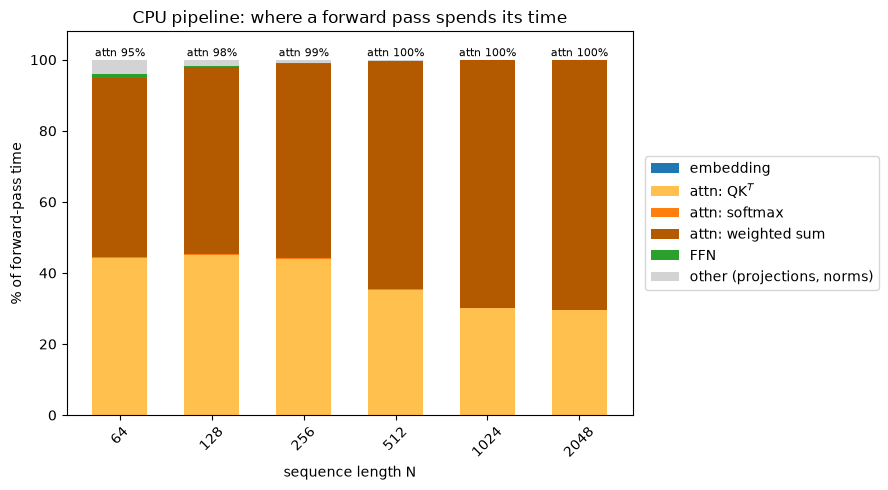

In [23]:
# Chart 1 -- share of forward-pass time per step (CPU pipeline)
import matplotlib.pyplot as plt
import numpy as np

PROFILE_LENS = [2 ** x for x in range(6, 12)]
pcts = [bench.step_percentages(cpu_model, n, warmup=False) for n in PROFILE_LENS]

parts = bench.STEPS + ["other"]
names = {"1_embedding": "embedding", "2a_qk_matmul": "attn: QK$^T$",
         "2b_softmax": "attn: softmax", "2c_value_weighted_sum": "attn: weighted sum",
         "3_ffn": "FFN", "other": "other (projections, norms)"}
colors = {"1_embedding": "tab:blue", "2a_qk_matmul": "#ffc04d", "2b_softmax": "tab:orange",
          "2c_value_weighted_sum": "#b35a00", "3_ffn": "tab:green", "other": "lightgray"}

fig, ax = plt.subplots(figsize=(9, 5))
xpos = np.arange(len(PROFILE_LENS))
bottom = np.zeros(len(PROFILE_LENS))
for part in parts:
    vals = np.array([p[part] for p in pcts])
    ax.bar(xpos, vals, 0.6, bottom=bottom, label=names[part], color=colors[part])
    bottom += vals

for xi, p in zip(xpos, pcts):  # annotate total attention share
    attn = sum(p[s] for s in bench.ATTN_STEPS)
    ax.text(xi, 101, f"attn {attn:.0f}%", ha="center", fontsize=8)

ax.set_xticks(xpos, PROFILE_LENS, rotation=45)
ax.set_xlabel("sequence length N")
ax.set_ylabel("% of forward-pass time")
ax.set_ylim(0, 108)
ax.set_title("CPU pipeline: where a forward pass spends its time")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

## Stage 2 — GPU versions

Two versions, one lesson each: V1 is the straight port — correct, massively
parallel, and wasteful with memory traffic; V2 shows where kernel speed
actually lives: data reuse.

**V1 — naive three-kernel** (`gpu_v1.py`): `_matmul` (QK$^T$), `_scale`,
`_softmax`, `_matmul` (weights·V) — four launches, and every intermediate
including the full N×N score matrix round-trips through global memory.
The matmul loads are coalesced (adjacent threads read adjacent addresses) but
nothing is reused, and the softmax — one thread per row, three reads of the
row — is fully uncoalesced; V2's block-per-row softmax fixes both.

**V2 — tiled QK$^T$ + online softmax** (`gpu_v2.py`): `_qkt_tiled` stages
16×16 tiles of Q and K in shared memory (each element is fetched from global
memory 16× less often; shared arrays are padded to dodge bank conflicts) and fuses
the $1/\sqrt{D}$ scaling into the epilogue. `_softmax_online` uses one block
per row: a running (max, sum) pair rescaled when the max moves — the
log-sum-exp trick — gets both out of **one** coalesced read of the row.

**Correctness contract:** every version must match
`torch.nn.functional.scaled_dot_product_attention` within 1e-4
(checked below and in `tests/test_correctness.py`).

In [24]:
# End-to-end correctness of each GPU version against torch SDPA
if cuda.is_available():
    x = torch.randint(0, 1000, (1, 128))
    for cls in (GpuV1, GpuV2):  # , GpuV3
        model = cls().eval()
        with torch.no_grad():
            torch.testing.assert_close(model(x), bench.sdpa_reference(model, x),
                                       atol=1e-4, rtol=1e-3)
        print(f"{cls.__name__}: matches torch SDPA within 1e-4")
else:
    print("No CUDA device -- skipping GPU correctness checks")

GpuV1: matches torch SDPA within 1e-4
GpuV2: matches torch SDPA within 1e-4


## Benchmark — attention step time

Timings cover the attention step only, on precomputed q, k, v, and *include*
the CPU→GPU→CPU transfers — the true cost of swapping a kernel into an
otherwise-CPU pipeline. N sweeps the powers of two from $2^6$ to $2^{11}$
(64 → 2048), covering every spec checkpoint (128 / 512 / 2048). Every number
is measured end to end — the CPU included, one pass per point (~7 min for its
column; that O(N²) cost is what caps the sweep).

In [25]:
SEQ_LENS = [2 ** x for x in range(6, 12)]

if cuda.is_available():
    classes = {"V1 naive": GpuV1,
               "V2 tiled + online softmax": GpuV2,
               # "V3 flash fused": GpuV3,
               }
    times = bench.bench_attention(classes, SEQ_LENS, reps=3)
    times["torch SDPA (GPU)"] = [bench.sdpa_gpu_ms(cpu_model, n, reps=3) for n in SEQ_LENS]
    torch.cuda.empty_cache()  # drop cached blocks so the sweep leaves no footprint

    # CPU measured last (slowest by far): one pass per point, ~7 min for the column
    times = {"CPU": [bench.attention_ms(cpu_model, n, reps=1, warmup=False)
                     for n in SEQ_LENS], **times}

    header = f"{'N':>6} " + "".join(f"{name:>28}" for name in times)
    print(header + "\n" + "-" * len(header))
    for i, n in enumerate(SEQ_LENS):
        print(f"{n:>6} " + "".join(f"{times[name][i]:>25.2f} ms" for name in times))
else:
    print("No CUDA device -- skipping the GPU benchmark")

COLORS = {"CPU": "tab:red",
          "V1 naive": "tab:blue", "V2 tiled + online softmax": "tab:orange",
          "V3 flash fused": "tab:green", "torch SDPA (GPU)": "gray"}

     N                          CPU                    V1 naive   V2 tiled + online softmax            torch SDPA (GPU)
-----------------------------------------------------------------------------------------------------------------------
    64                    285.36 ms                     2.45 ms                     1.96 ms                     0.56 ms
   128                   1144.29 ms                     2.34 ms                     2.08 ms                     0.69 ms
   256                   4674.52 ms                     2.81 ms                     2.42 ms                     0.99 ms
   512                  24105.36 ms                     3.86 ms                     3.27 ms                     1.65 ms
  1024                 113054.64 ms                     7.69 ms                     4.80 ms                     2.52 ms
  2048                 465050.12 ms                    21.93 ms                    10.73 ms                     4.80 ms


## Attention kernel throughput — TFLOP/s and bandwidth utilisation

How close do the kernels get to the hardware limits? Following the HW02
roofline methodology: **device-resident timing with CUDA events** (no
transfers in the timed region), FLOPs counted from the algorithm, and a
dominant-term **global-memory traffic model** per version.

- **FLOPs**: two N×N×D matmuls plus the softmax ≈ $4N^2D + 5N^2$
- **Traffic** (fp32 = 4 B/element):

| version | bytes moved | why |
|---|---|---|
| V1 naive | $4\,(4N^2D + 6N^2)$ | matmul operands re-read from global memory per output element |
| V2 tiled | $4\,(4N^2D/16 + 4N^2)$ | shared-memory tiles: each operand element read once per 16-tile |

Arithmetic intensity is the whole story of V1→V2: ≈0.25 FLOP/B (naive) →
≈4 (tiled) — the step climbs the roofline by increasing data reuse. torch SDPA
appears in the TFLOP/s chart (Chart 4) as the reference; its ~7× lead over V2
is the next rung of that same ladder — fusion, so the N×N matrix never touches
global memory at all. Its internal traffic is not ours to model, so it is left
out of the utilisation chart (Chart 5).

Note the models count **requested** bytes. At N ≤ 2048 the N×N score matrix
(≤ 17 MB fp32) fits in the L4's 48 MB L2, so requested-traffic rates can sit
*above* the DRAM ceiling for both kernels. Read Chart 5 comparatively: V1 asks
the memory system for ~16× more bytes than V2 for the same math; the cache
hierarchy absorbs part of that redundancy, and what it cannot absorb is V1's
~3× kernel-time deficit at N = 2048.

In [26]:
# Kernel-only timing sweep (CUDA events, device-resident) + hardware peaks
if cuda.is_available():
    specs = bench.gpu_specs()
    print(f"GPU: {specs['name']} | {specs['sm']} SMs | "
          f"peak {specs['tflops']:.1f} TFLOP/s fp32 | peak {specs['bw_gbs']:.0f} GB/s")

    D_MODEL = 512
    FLOPS = lambda n: 4 * n * n * D_MODEL + 5 * n * n
    TRAFFIC = {  # bytes of global-memory traffic (dominant terms, fp32 = 4 B)
        "V1 naive": lambda n: 4 * (4 * n * n * D_MODEL + 6 * n * n),
        "V2 tiled + online softmax": lambda n: 4 * (4 * n * n * D_MODEL / 16 + 4 * n * n),
        # "V3 flash fused": lambda n: 4 * (n * n * D_MODEL / 16 + 2 * n * D_MODEL),
    }

    kmodels = {"V1 naive": GpuV1().eval(),
               "V2 tiled + online softmax": GpuV2().eval(),
               # "V3 flash fused": GpuV3().eval(),
               }
    REPS = lambda n: 10 if n <= 4096 else 3  # HW01 uses 10; large N costs seconds
    ktimes = {name: [bench.attention_kernel_ms(m, n, reps=REPS(n)) for n in SEQ_LENS]
              for name, m in kmodels.items()}
    ktimes["torch SDPA (GPU)"] = [bench.sdpa_kernel_ms(cpu_model, n, reps=REPS(n))
                                  for n in SEQ_LENS]
    torch.cuda.empty_cache()  # drop the dead N x N blocks V1/V2 leave cached

    header = f"{'N':>6}" + "".join(f"{name:>30}" for name in ktimes)
    print("\n" + header + "   (kernel-only ms)\n" + "-" * len(header))
    for i, n in enumerate(SEQ_LENS):
        print(f"{n:>6}" + "".join(f"{ktimes[name][i]:>27.3f} ms" for name in ktimes))
else:
    print("No CUDA device -- skipping the kernel metrics")

GPU: NVIDIA L4 | 58 SMs | peak 30.3 TFLOP/s fp32 | peak 300 GB/s

     N                      V1 naive     V2 tiled + online softmax              torch SDPA (GPU)   (kernel-only ms)
------------------------------------------------------------------------------------------------
    64                      1.656 ms                      1.403 ms                      0.217 ms
   128                      1.637 ms                      1.415 ms                      0.215 ms
   256                      1.616 ms                      1.427 ms                      0.202 ms
   512                      1.631 ms                      1.528 ms                      0.226 ms
  1024                      4.658 ms                      1.483 ms                      0.242 ms
  2048                     19.860 ms                      5.944 ms                      0.872 ms


### Transfer cost — compute-only vs with-transfer (HW01 stage-5 analysis)

The end-to-end benchmark pays the CPU→GPU→CPU copy on every call; the kernel
sweep does not. Their difference is the price of swapping a GPU kernel into a
CPU pipeline: the copy grows O(N) while compute grows O(N²), so the share falls
once compute outgrows the launch-and-copy floor — soonest for the slowest
kernel (V1, a few % by N = 2048), last for the fastest (torch SDPA, still
~80% overhead at the top of the sweep). Chart 2 traces exactly that.

In [27]:
if cuda.is_available():
    name = "V2 tiled + online softmax"
    print(f"{'N':>6} {'with transfer':>14} {'kernel only':>12} {'overhead':>10} {'share':>7}")
    for i, n in enumerate(SEQ_LENS):
        e2e, kern = times[name][i], ktimes[name][i]
        over = max(e2e - kern, 0.0)
        print(f"{n:>6} {e2e:>11.2f} ms {kern:>9.3f} ms {over:>7.2f} ms {over / e2e * 100:>6.0f}%")
    moved = 16 * SEQ_LENS[-1] * 512  # q,k,v up + out down, fp32 bytes
    over = max(times[name][-1] - ktimes[name][-1], 1e-9)
    print(f"\nAt N={SEQ_LENS[-1]}: {moved / 1e6:.0f} MB moved -> "
          f"~{moved / (over / 1e3) / 1e9:.1f} GB/s effective transfer rate")

     N  with transfer  kernel only   overhead   share
    64        1.96 ms     1.403 ms    0.56 ms     28%
   128        2.08 ms     1.415 ms    0.67 ms     32%
   256        2.42 ms     1.427 ms    1.00 ms     41%
   512        3.27 ms     1.528 ms    1.74 ms     53%
  1024        4.80 ms     1.483 ms    3.32 ms     69%
  2048       10.73 ms     5.944 ms    4.79 ms     45%

At N=2048: 17 MB moved -> ~3.5 GB/s effective transfer rate


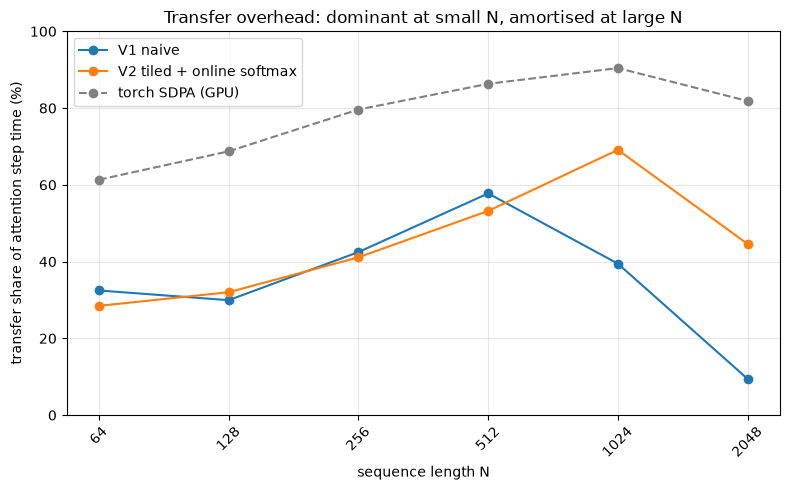

In [28]:
# Chart 2 -- transfer share of the attention step: (with transfer - kernel) / with transfer
if cuda.is_available():
    fig, ax = plt.subplots(figsize=(8, 5))
    for name in ktimes:
        shares = [max(e - k, 0.0) / e * 100 for e, k in zip(times[name], ktimes[name])]
        ax.plot(SEQ_LENS, shares, marker="o", color=COLORS[name],
                linestyle="--" if "SDPA" in name else "-", label=name)
    ax.set_xscale("log", base=2)
    ax.set_xticks(SEQ_LENS, SEQ_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_ylabel("transfer share of attention step time (%)")
    ax.set_ylim(0, 100)
    ax.set_title("Transfer overhead: dominant at small N, amortised at large N")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

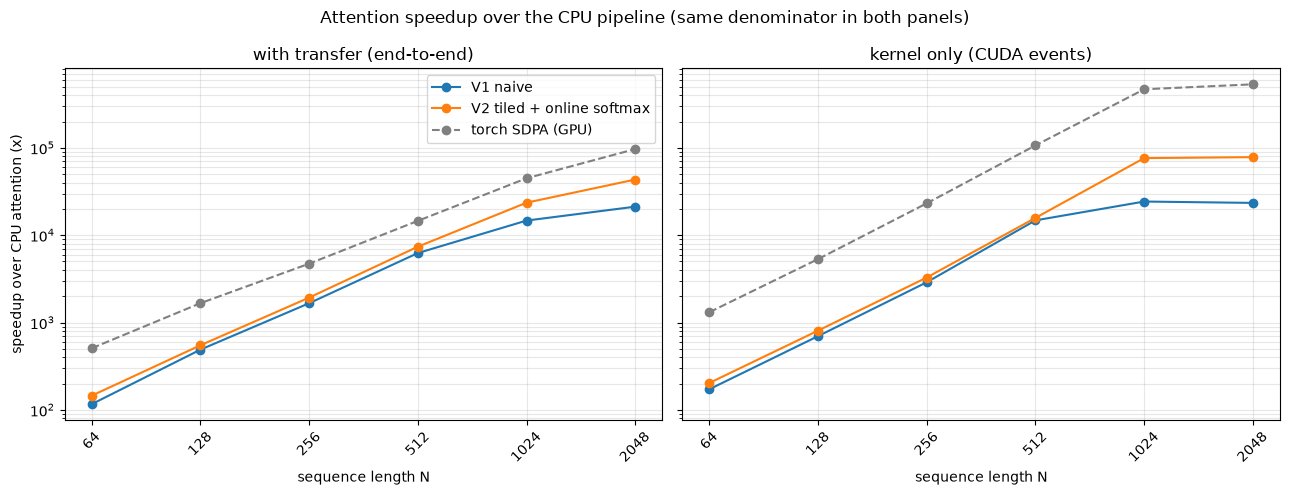

In [29]:
# Chart 3 -- speedup over the CPU attention step: with transfer vs kernel only
if cuda.is_available():
    cpu_ms = times["CPU"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for ax, (title, data) in zip(axes, [("with transfer (end-to-end)", times),
                                        ("kernel only (CUDA events)", ktimes)]):
        for name, ts in data.items():
            if name == "CPU":
                continue
            speedups = [c / t for c, t in zip(cpu_ms, ts)]
            ax.plot(SEQ_LENS, speedups, marker="o", color=COLORS[name],
                    linestyle="--" if "SDPA" in name else "-", label=name)
        ax.set_xscale("log", base=2)
        ax.set_yscale("log")
        ax.set_xticks(SEQ_LENS, SEQ_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_title(title)
        ax.grid(True, which="both", alpha=0.3)
    axes[0].set_ylabel("speedup over CPU attention (x)")
    axes[0].legend()
    plt.suptitle("Attention speedup over the CPU pipeline (same denominator in both panels)")
    plt.tight_layout()
    plt.show()

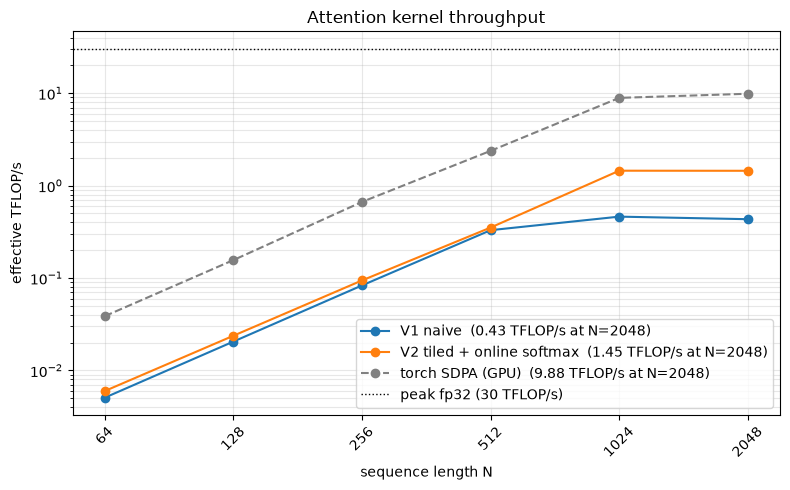

In [30]:
# Chart 4 -- effective TFLOP/s per kernel
if cuda.is_available():
    fig, ax = plt.subplots(figsize=(8, 5))
    for name, ts in ktimes.items():
        tflops = [FLOPS(n) / (t / 1e3) / 1e12 for n, t in zip(SEQ_LENS, ts)]
        ax.plot(SEQ_LENS, tflops, marker="o", color=COLORS[name],
                linestyle="--" if "SDPA" in name else "-",
                label=f"{name}  ({tflops[-1]:.2f} TFLOP/s at N={SEQ_LENS[-1]})")
    ax.axhline(specs["tflops"], color="black", linestyle=":", linewidth=1,
               label=f"peak fp32 ({specs['tflops']:.0f} TFLOP/s)")
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(SEQ_LENS, SEQ_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_ylabel("effective TFLOP/s")
    ax.set_title("Attention kernel throughput")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

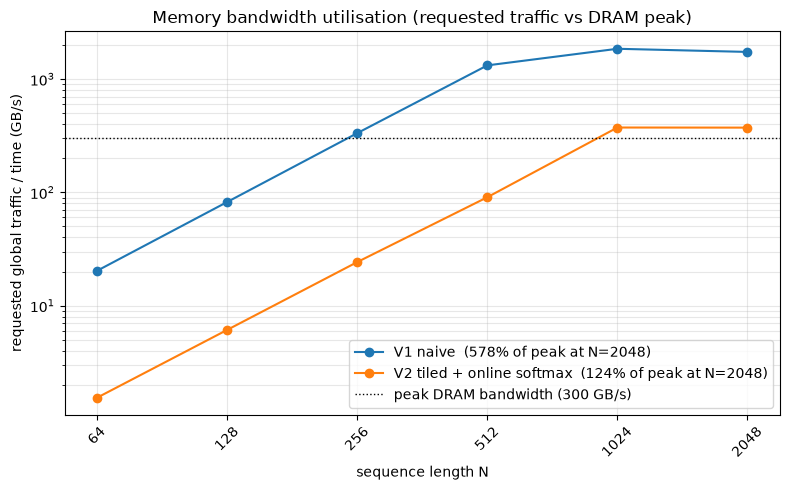

In [31]:
# Chart 5 -- effective global-memory throughput vs the DRAM ceiling
if cuda.is_available():
    fig, ax = plt.subplots(figsize=(8, 5))
    for name, traffic in TRAFFIC.items():
        gbs = [traffic(n) / (t / 1e3) / 1e9 for n, t in zip(SEQ_LENS, ktimes[name])]
        pct = gbs[-1] / specs["bw_gbs"] * 100
        ax.plot(SEQ_LENS, gbs, marker="o", color=COLORS[name],
                label=f"{name}  ({pct:.0f}% of peak at N={SEQ_LENS[-1]})")
    ax.axhline(specs["bw_gbs"], color="black", linestyle=":", linewidth=1,
               label=f"peak DRAM bandwidth ({specs['bw_gbs']:.0f} GB/s)")
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(SEQ_LENS, SEQ_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_ylabel("requested global traffic / time (GB/s)")
    ax.set_title("Memory bandwidth utilisation (requested traffic vs DRAM peak)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Conclusion

Chart 1 picked the target — attention is essentially the whole forward pass —
and replacing just that step takes N = 2048 attention from ~5 min on the CPU
to ~11 ms with V2, transfers included (~3×10⁴×; even naive V1 lands ~10⁴×).
The GPU-side tax is the pipeline boundary, not compute: transfer overhead
dominates at small N and amortises as O(N²) compute grows (Chart 2).

The roofline explains the kernel ladder. V1 is coalesced but reuse-free
(≈0.25 FLOP/B); V2 requests 16× fewer bytes for the same math and turns that
into ~3× over V1 kernel-to-kernel. The remaining ~7× to torch SDPA is
algorithmic, not tuning: fuse the whole pipeline so the N×N matrix never
exists. Fewer bytes, not better scheduling, is the next step.